# Plotting Utilities Notebook

This notebook is the notebook version of `utils.py`, adapted to this repo layout. It reads result `.npz` files from the project root, renders figures inline, and saves the main panel figure to `figures/mmd_flow.pdf`.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = Path.cwd()
RESULTS_DIR = ROOT
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_FIGURE = FIGURES_DIR / "mmd_flow.pdf"

FIGSIZE = (6, 4)
DPI = 100
TITLE_SIZE = 24
LABEL_SIZE = 20
TICK_SIZE = 16
LEGEND_SIZE = 32
MARKER_SIZE = 4.5
LINE_WIDTH = 2.0
TITLE_PAD = 8
FOUR_PANEL_LEGEND_SIZE = 28
COLORS = {"mmd": "#d95f02", "smmd": "#1b9e77", "svgd": "#7570b3"}

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)
ROOT, RESULTS_DIR, OUTPUT_FIGURE

(PosixPath('/home/zongchen/MDF_AL'),
 PosixPath('/home/zongchen/MDF_AL'),
 PosixPath('/home/zongchen/MDF_AL/figures/mmd_flow.pdf'))

In [2]:
def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _sample_target_mog(num_samples, seed=0, radius=2.0, std=0.2, k=8):
    rng = np.random.default_rng(seed)
    angles = 2.0 * np.pi * np.arange(k, dtype=np.float64) / k
    means = np.stack(
        [radius * np.cos(angles), radius * np.sin(angles)],
        axis=1,
    )
    component_ids = rng.integers(0, k, size=num_samples)
    return means[component_ids] + rng.normal(scale=std, size=(num_samples, 2))


def _comparison_plot_limits(target_samples, fixed_samples, adaptive_samples):
    all_samples = np.vstack([target_samples, fixed_samples, adaptive_samples])
    mins = all_samples.min(axis=0)
    maxs = all_samples.max(axis=0)
    center = 0.5 * (mins + maxs)
    span = np.max(maxs - mins)
    half_width = 0.55 * span
    x_min, x_max = center[0] - half_width, center[0] + half_width
    y_min, y_max = center[1] - half_width, center[1] + half_width

    return x_min, x_max, y_min, y_max


def _draw_comparison_plot(ax, target_samples, fixed_samples, adaptive_samples, show_legend=True):
    x_min, x_max, y_min, y_max = _comparison_plot_limits(
        target_samples,
        fixed_samples,
        adaptive_samples,
    )
    ax.scatter(
        fixed_samples[:, 0],
        fixed_samples[:, 1],
        s=7,
        c=COLORS["mmd"],
        alpha=0.55,
        edgecolors="none",
        label="Fixed",
    )
    ax.scatter(
        adaptive_samples[:, 0],
        adaptive_samples[:, 1],
        s=7,
        c=COLORS["smmd"],
        alpha=0.45,
        edgecolors="none",
        label="Adaptive",
    )
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.15, linewidth=0.8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if show_legend:
        ax.legend(loc="upper right", frameon=True)


def _draw_mmd_vs_n_plot(ax, ns, fixed_mmd, adaptive_mmd, show_legend=True, show_ylabel=True):
    ns = np.asarray(ns, dtype=float)
    fixed_mmd = np.asarray(fixed_mmd, dtype=float)
    adaptive_mmd = np.asarray(adaptive_mmd, dtype=float)
    ax.plot(ns, fixed_mmd, marker="o", color=COLORS["mmd"], label="Fixed")
    ax.plot(ns, adaptive_mmd, marker="o", color=COLORS["smmd"], label="Adaptive")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("n")
    if show_ylabel:
        ax.set_ylabel("MMD")
    ax.grid(True, which="major", alpha=0.15, linewidth=0.8)
    if show_legend:
        ax.legend(frameon=True)


def _draw_mmd_vs_iteration_plot(ax, fixed_mmd, adaptive_mmd, show_legend=True, show_ylabel=True):
    fixed_mmd = np.asarray(fixed_mmd, dtype=float)
    adaptive_mmd = np.asarray(adaptive_mmd, dtype=float)
    fixed_steps = np.arange(1, fixed_mmd.shape[0] + 1, dtype=float)
    adaptive_steps = np.arange(1, adaptive_mmd.shape[0] + 1, dtype=float)
    ax.plot(fixed_steps, fixed_mmd, color=COLORS["mmd"], label="Fixed")
    ax.plot(adaptive_steps, adaptive_mmd, color=COLORS["smmd"], label="Adaptive")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    if show_ylabel:
        ax.set_ylabel("MMD")
    # ax.set_title("MMD vs Iteration", pad=TITLE_PAD)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend(frameon=True)


def _draw_lhs_rhs_plot(ax, steps, lhs, rhs, show_legend=True, show_ylabel=True):
    steps = np.asarray(steps, dtype=float)
    lhs = np.asarray(lhs, dtype=float)
    rhs = np.asarray(rhs, dtype=float)
    ax.plot(steps, lhs, color="#D62728", label="LHS")
    ax.plot(steps, rhs, color="#111111", label="RHS")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    if show_ylabel:
        ax.set_ylabel("Value")
    ax.set_title("LHS vs RHS", pad=TITLE_PAD)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend(frameon=True)


def make_comparison_plot(
    target_samples,
    fixed_samples,
    adaptive_samples,
    fixed_mmd,
    adaptive_mmd,
):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_comparison_plot(ax, target_samples, fixed_samples, adaptive_samples)
        fig.tight_layout()
        return fig


def make_mmd_vs_n_plot(ns, fixed_mmd, adaptive_mmd):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_mmd_vs_n_plot(ax, ns, fixed_mmd, adaptive_mmd)
        fig.tight_layout()
        return fig


def make_mmd_vs_iteration_plot(fixed_mmd, adaptive_mmd):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_mmd_vs_iteration_plot(ax, fixed_mmd, adaptive_mmd)
        fig.tight_layout()
        return fig


def make_lhs_rhs_plot(steps, lhs, rhs):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_lhs_rhs_plot(ax, steps, lhs, rhs)
        fig.tight_layout()
        return fig


def make_mmd_vs_iteration_plot_from_npz(npz_path):
    data = _load_npz_dict(npz_path)
    fixed_hists = np.asarray(data["fixed_hists"], dtype=float)
    adaptive_hists = np.asarray(data["adapt_hists"], dtype=float)
    fixed_mmd = np.sqrt(np.maximum(2.0 * fixed_hists.mean(axis=0), 0.0))
    adaptive_mmd = np.sqrt(np.maximum(2.0 * adaptive_hists.mean(axis=0), 0.0))
    return make_mmd_vs_iteration_plot(fixed_mmd, adaptive_mmd)


def make_lhs_rhs_plot_from_npz(npz_path):
    data = _load_npz_dict(npz_path)
    steps = np.asarray(data["last_adapt_checkpoint_steps"], dtype=float)
    lhs = np.asarray(data["last_adapt_lhs"], dtype=float)
    rhs = np.asarray(data["last_adapt_rhs"], dtype=float)
    return make_lhs_rhs_plot(steps, lhs, rhs)


def make_comparison_plot_from_npz(
    npz_path,
    num_target_samples=5000,
    target_seed=0,
    radius=2.0,
    std=0.2,
    k=8,
):
    data = _load_npz_dict(npz_path)
    target_samples = _sample_target_mog(
        num_samples=num_target_samples,
        seed=target_seed,
        radius=radius,
        std=std,
        k=k,
    )
    fixed_samples = np.asarray(data["last_fixed_particles"], dtype=float)
    adaptive_samples = np.asarray(data["last_adapt_particles"], dtype=float)
    fixed_mmd = np.sqrt(max(2.0 * float(data["fixed_mean"]), 0.0))
    adaptive_mmd = np.sqrt(max(2.0 * float(data["adapt_mean"]), 0.0))
    return make_comparison_plot(
        target_samples=target_samples,
        fixed_samples=fixed_samples,
        adaptive_samples=adaptive_samples,
        fixed_mmd=fixed_mmd,
        adaptive_mmd=adaptive_mmd,
    )


def make_mmd_vs_n_plot_from_npz(npz_paths, ns):
    fixed_mmd = []
    adaptive_mmd = []

    for npz_path in npz_paths:
        data = _load_npz_dict(npz_path)
        fixed_mmd.append(np.sqrt(max(2.0 * float(data["fixed_mean"]), 0.0)))
        adaptive_mmd.append(np.sqrt(max(2.0 * float(data["adapt_mean"]), 0.0)))

    return make_mmd_vs_n_plot(
        ns=np.asarray(ns, dtype=float),
        fixed_mmd=np.asarray(fixed_mmd, dtype=float),
        adaptive_mmd=np.asarray(adaptive_mmd, dtype=float),
    )


def make_four_panel_figure(
    comparison_npz,
    mmd_vs_n_npz_paths,
    mmd_vs_n_ns,
    mmd_vs_iteration_npz,
    lhs_rhs_npz,
):
    comparison_data = _load_npz_dict(comparison_npz)
    target_samples = _sample_target_mog(num_samples=5000, seed=0, radius=2.0, std=0.2, k=8)
    fixed_samples = np.asarray(comparison_data["last_fixed_particles"], dtype=float)
    adaptive_samples = np.asarray(comparison_data["last_adapt_particles"], dtype=float)

    mmd_vs_n_fixed = []
    mmd_vs_n_adaptive = []
    for npz_path in mmd_vs_n_npz_paths:
        data = _load_npz_dict(npz_path)
        mmd_vs_n_fixed.append(np.sqrt(max(2.0 * float(data["fixed_mean"]), 0.0)))
        mmd_vs_n_adaptive.append(np.sqrt(max(2.0 * float(data["adapt_mean"]), 0.0)))
    mmd_vs_n_fixed = np.asarray(mmd_vs_n_fixed, dtype=float)
    mmd_vs_n_adaptive = np.asarray(mmd_vs_n_adaptive, dtype=float)
    mmd_vs_n_ns = np.asarray(mmd_vs_n_ns, dtype=float)

    iteration_data = _load_npz_dict(mmd_vs_iteration_npz)
    fixed_hists = np.asarray(iteration_data["fixed_hists"], dtype=float)
    adaptive_hists = np.asarray(iteration_data["adapt_hists"], dtype=float)
    iteration_fixed_mmd = np.sqrt(np.maximum(2.0 * fixed_hists.mean(axis=0), 0.0))
    iteration_adaptive_mmd = np.sqrt(np.maximum(2.0 * adaptive_hists.mean(axis=0), 0.0))

    lhs_rhs_data = _load_npz_dict(lhs_rhs_npz)
    lhs_rhs_steps = np.asarray(lhs_rhs_data["last_adapt_checkpoint_steps"], dtype=float)
    lhs_values = np.asarray(lhs_rhs_data["last_adapt_lhs"], dtype=float)
    rhs_values = np.asarray(lhs_rhs_data["last_adapt_rhs"], dtype=float)

    top_legend_handles = [
        Line2D([0], [0], color=COLORS["mmd"], marker="o", lw=2, label="Fixed"),
        Line2D([0], [0], color=COLORS["smmd"], marker="o", lw=2, label="Adaptive"),
    ]

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(
            1,
            4,
            figsize=(24, 5),
            dpi=100,
            gridspec_kw={"width_ratios": [1.0, 1.0, 1.0, 1.0]},
        )
        ax_comparison, ax_mmd_n, ax_mmd_iter, ax_lhs_rhs = axes

        _draw_comparison_plot(
            ax_comparison,
            target_samples,
            fixed_samples,
            adaptive_samples,
            show_legend=False,
        )
        _draw_mmd_vs_n_plot(
            ax_mmd_n,
            mmd_vs_n_ns,
            mmd_vs_n_fixed,
            mmd_vs_n_adaptive,
            show_legend=False,
        )
        _draw_mmd_vs_iteration_plot(
            ax_mmd_iter,
            iteration_fixed_mmd,
            iteration_adaptive_mmd,
            show_legend=False,
        )
        _draw_lhs_rhs_plot(
            ax_lhs_rhs,
            lhs_rhs_steps,
            lhs_values,
            rhs_values,
        )

        fig.legend(
            handles=top_legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.1),
            ncol=2,
            fancybox=False,
            facecolor="white",
            fontsize=FOUR_PANEL_LEGEND_SIZE,
        )
        fig.tight_layout(rect=(0, 0, 1, 0.95))
        return fig


## Local file setup

These defaults match the files that already exist in this repo. The iteration-history and `lhs/rhs` inputs are optional because they are not currently present in this workspace.

In [3]:
comparison_npz = RESULTS_DIR / "results_n300.npz"
mmd_vs_n_npz_paths = [
    RESULTS_DIR / "results_n10.npz",
    RESULTS_DIR / "results_n30.npz",
    RESULTS_DIR / "results_n100.npz",
    RESULTS_DIR / "results_n300.npz",
]
mmd_vs_n_ns = [10, 30, 100, 300]
mmd_vs_iteration_npz = RESULTS_DIR / "mmd_iteration_100.npz"
lhs_rhs_npz = RESULTS_DIR / "lhs_rhs.npz"

{
    "comparison_npz": comparison_npz,
    "mmd_vs_n_npz_paths": mmd_vs_n_npz_paths,
    "mmd_vs_iteration_npz": mmd_vs_iteration_npz,
    "lhs_rhs_npz": lhs_rhs_npz,
}

{'comparison_npz': PosixPath('/home/zongchen/MDF_AL/results_n300.npz'),
 'mmd_vs_n_npz_paths': [PosixPath('/home/zongchen/MDF_AL/results_n10.npz'),
  PosixPath('/home/zongchen/MDF_AL/results_n30.npz'),
  PosixPath('/home/zongchen/MDF_AL/results_n100.npz'),
  PosixPath('/home/zongchen/MDF_AL/results_n300.npz')],
 'mmd_vs_iteration_npz': PosixPath('/home/zongchen/MDF_AL/mmd_iteration_100.npz'),
 'lhs_rhs_npz': PosixPath('/home/zongchen/MDF_AL/lhs_rhs.npz')}

In [4]:
available_inputs = {
    "comparison_npz": comparison_npz.exists(),
    "mmd_vs_n_npz_paths": [path.exists() for path in mmd_vs_n_npz_paths],
    "mmd_vs_iteration_npz": mmd_vs_iteration_npz.exists(),
    "lhs_rhs_npz": lhs_rhs_npz.exists(),
}
available_inputs

{'comparison_npz': True,
 'mmd_vs_n_npz_paths': [True, True, True, True],
 'mmd_vs_iteration_npz': True,
 'lhs_rhs_npz': True}

Saved figure to /home/zongchen/MDF_AL/figures/mmd_flow.pdf


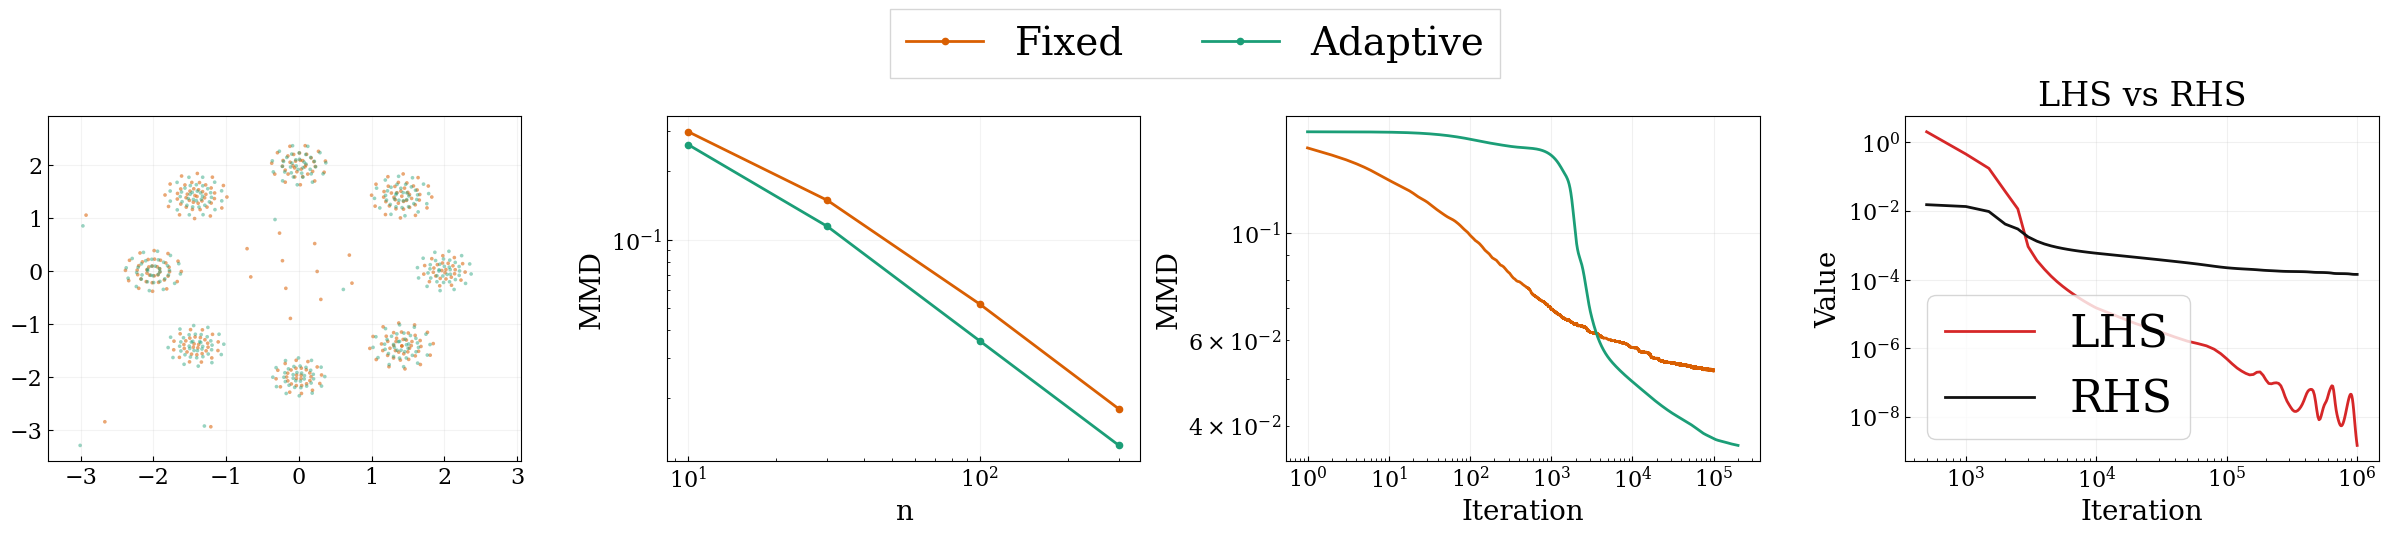

In [5]:
required_inputs = [comparison_npz, *mmd_vs_n_npz_paths, mmd_vs_iteration_npz, lhs_rhs_npz]
missing_inputs = [path for path in required_inputs if not path.exists()]

if not missing_inputs:
    fig = make_four_panel_figure(
        comparison_npz=comparison_npz,
        mmd_vs_n_npz_paths=mmd_vs_n_npz_paths,
        mmd_vs_n_ns=mmd_vs_n_ns,
        mmd_vs_iteration_npz=mmd_vs_iteration_npz,
        lhs_rhs_npz=lhs_rhs_npz,
    )
    fig.savefig(OUTPUT_FIGURE, bbox_inches="tight")
    print(f"Saved figure to {OUTPUT_FIGURE}")
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )


In [6]:
# Figures render inline in the previous cell and are also saved to OUTPUT_FIGURE.